In [348]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,mean_squared_error, r2_score

In [349]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [350]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [351]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [352]:
train.shape

(106, 14)

In [353]:
train= train.asfreq('MS')

In [354]:
test= test.asfreq('MS')

In [355]:
simple_model= SimpleExpSmoothing(train['#Passengers'].ffill()).fit()

In [356]:
simple_pred= simple_model.forecast(len(test))

In [357]:
simple_pred

1959-09-01    559.0
1959-10-01    559.0
1959-11-01    559.0
1959-12-01    559.0
1960-01-01    559.0
1960-02-01    559.0
1960-03-01    559.0
1960-04-01    559.0
1960-05-01    559.0
1960-06-01    559.0
1960-07-01    559.0
1960-08-01    559.0
1960-09-01    559.0
1960-10-01    559.0
1960-11-01    559.0
1960-12-01    559.0
Freq: MS, dtype: float64

In [358]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(mean_squared_error(test,predictions, squared=False), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

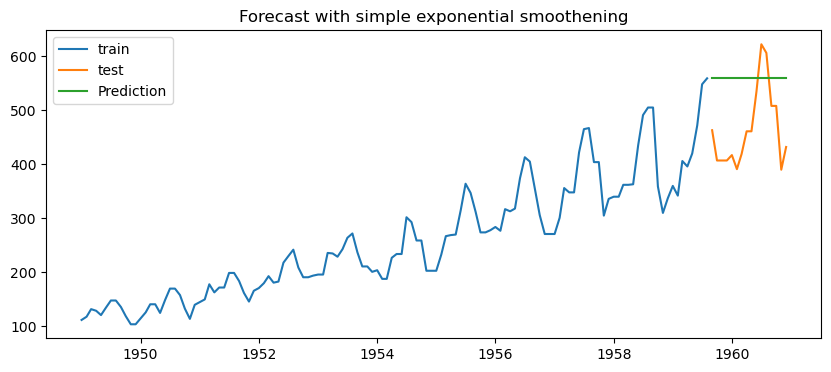

mean absolute error: 108.12
mean absolute percentage error: 25.0%
r2 score: -1.78
root mean squared error: 117.89


C:\ProgramData\new\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [378]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),simple_pred, 'simple exponential smoothening')

In [370]:
#  Double model

double_smoothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal=None,
                                         trend='add',
                                         ).fit()

In [371]:
double_pred= double_smoothening.forecast(len(test))

In [372]:
double_pred

1959-09-01    562.519690
1959-10-01    566.039379
1959-11-01    569.559069
1959-12-01    573.078759
1960-01-01    576.598449
1960-02-01    580.118138
1960-03-01    583.637828
1960-04-01    587.157518
1960-05-01    590.677208
1960-06-01    594.196897
1960-07-01    597.716587
1960-08-01    601.236277
1960-09-01    604.755967
1960-10-01    608.275656
1960-11-01    611.795346
1960-12-01    615.315036
Freq: MS, dtype: float64

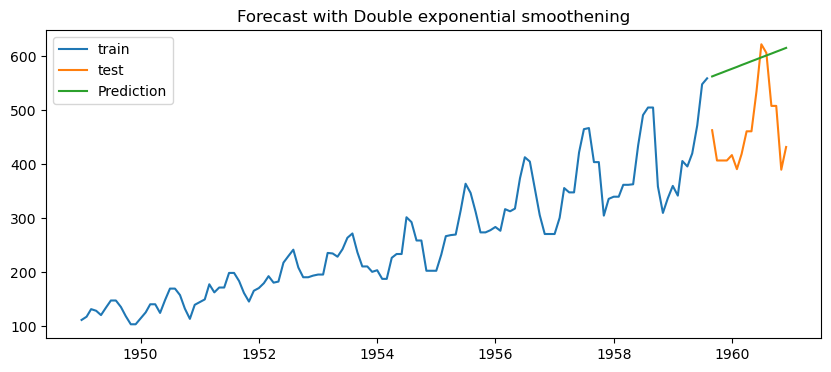

mean absolute error: 127.92
mean absolute percentage error: 30.0%
r2 score: -2.96
root mean squared error: 140.67


C:\ProgramData\new\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [377]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),double_pred, 'Double exponential smoothening')

In [417]:
thriple_smothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal='mul',
                                         trend='mul',
                                         seasonal_periods=12).fit()

In [418]:
thriple_pred= thriple_smothening.forecast(len(test))

In [419]:
thriple_pred

1959-09-01    500.460336
1959-10-01    432.750568
1959-11-01    376.192229
1959-12-01    394.986525
1960-01-01    405.559263
1960-02-01    410.181372
1960-03-01    466.040304
1960-04-01    463.567571
1960-05-01    469.927338
1960-06-01    539.321455
1960-07-01    611.959635
1960-08-01    615.172006
1960-09-01    558.133249
1960-10-01    482.620626
1960-11-01    419.544519
1960-12-01    440.504664
Freq: MS, dtype: float64

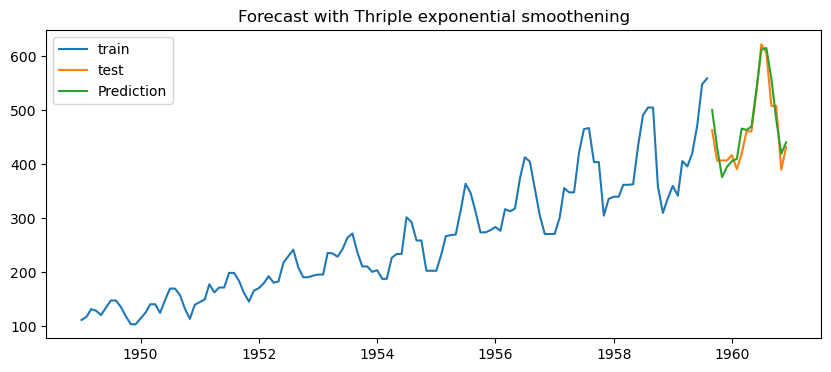

mean absolute error: 20.77
mean absolute percentage error: 5.0%
r2 score: 0.87
root mean squared error: 25.33


C:\ProgramData\new\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [420]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),thriple_pred, 'Thriple exponential smoothening')

In [379]:
test.isnull().sum()

#Passengers       4
month             4
quater            4
lag1              4
lag2              4
lag3              4
lag6              4
lag12             4
rolling_mean3     4
rolling_std3      4
rolling_mean6     4
rolling_std6      4
rolling_mean12    4
rolling_std12     4
dtype: int64

In [380]:
train.isnull().sum()

#Passengers       22
month             22
quater            22
lag1              23
lag2              24
lag3              25
lag6              28
lag12             34
rolling_mean3     24
rolling_std3      24
rolling_mean6     27
rolling_std6      27
rolling_mean12    33
rolling_std12     33
dtype: int64

In [381]:
df.isnull().sum()

#Passengers        0
month              0
quater             0
lag1               1
lag2               2
lag3               3
lag6               6
lag12             12
rolling_mean3      2
rolling_std3       2
rolling_mean6      5
rolling_std6       5
rolling_mean12    11
rolling_std12     11
dtype: int64

In [389]:
df=df.asfreq('MS')

In [390]:
# Predicting the future

final_exponential_sommthening= ExponentialSmoothing(df['#Passengers'].ffill(),
                                                   seasonal='mul',
                                                  trend='mul',
                                                  seasonal_periods=12 ).fit()

In [391]:
next_12_months= final_exponential_sommthening.forecast(12)

In [392]:
next_12_months

1961-01-01    443.329166
1961-02-01    441.064688
1961-03-01    495.317352
1961-04-01    503.221147
1961-05-01    508.714415
1961-06-01    585.227072
1961-07-01    667.573231
1961-08-01    666.741146
1961-09-01    587.381019
1961-10-01    525.591300
1961-11-01    455.759650
1961-12-01    479.821975
Freq: MS, dtype: float64

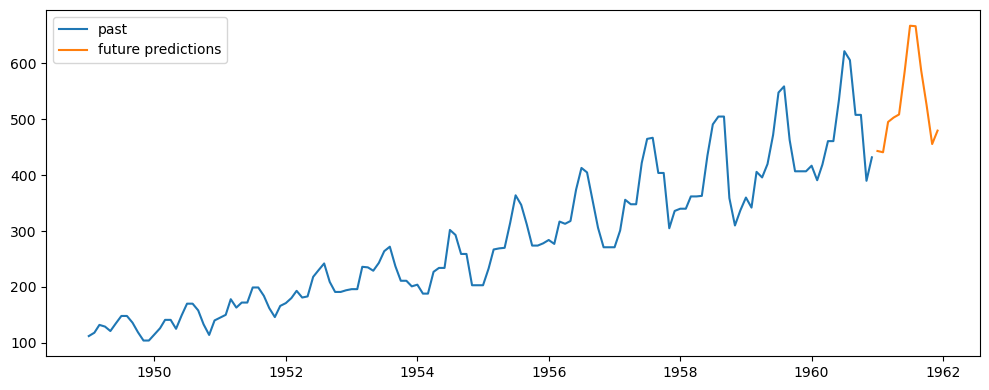

In [396]:
plt.figure(figsize=(10,4))

plt.plot(df['#Passengers'].ffill(), label= 'past')
plt.plot(next_12_months, label='future predictions')

plt.legend()
plt.tight_layout()
plt.show()

In [421]:
joblib.dump(final_exponential_sommthening, r"C:\Users\MINE\Desktop\Air passenger prediction\models\expo_smoothening.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\expo_smoothening.pkl']